In [18]:
!pip install pyspice
!pip install graphviz

ERROR: Could not find a version that satisfies the requirement ngspice (from versions: none)
ERROR: No matching distribution found for ngspice
/bin/bash: line 1: conda: command not found


In [19]:
import PySpice
print(PySpice.__version__)

1.5


In [21]:
!sudo apt-get update
!sudo apt-get install -y ngspice
!ngspice --version

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [31]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Unit import *
from PySpice.Probe.Plot import plot
from matplotlib.pyplot import show
from graphviz import Digraph


.title Exercise 10
.title Exercise 10
V1 N1 0 9V
R1 N1 N2 600Ohm
R2 N2 0 750Ohm
R3 N2 0 1kOhm

.op
.print op v(N1) v(N2) i(V1)
.end


No compatibility mode selected!


Circuit: Exercise 10

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 1
	Node                                  Voltage
	----                                  -------
	----	-------
	n2                               3.750000e+00
	n1                               9.000000e+00

	Source	Current
	------	-------

	v1#branch                        -8.75000e-03

 Resistor models (Simple linear resistor)
      model                     R

        rsh                     0
     narrow                     0
      short                     0
        tc1                     0
        tc2                     0
        tce                     0
       defw                 1e-05
          l                 1e-05
         kf                     0
         af                     0
          r                  

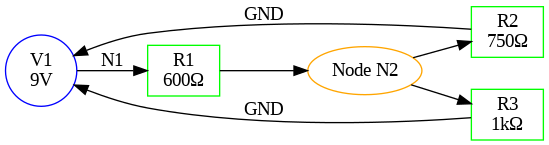

In [45]:
# Import necessary libraries
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from graphviz import Digraph
from IPython.display import Image
import subprocess

# Define the circuit
circuit = Circuit('Exercise 10')

# Add elements to the circuit
circuit.V(1, 'N1', circuit.gnd, 9@u_V)   # Voltage source (9V)
circuit.R(1, 'N1', 'N2', 600@u_Ohm)        # Resistor R1 (600 Ω)
circuit.R(2, 'N2', circuit.gnd, 750@u_Ohm) # Resistor R2 (750 Ω)
circuit.R(3, 'N2', circuit.gnd, 1@u_kOhm)  # Resistor R3 (1 kΩ)

# Manually add simulation commands to the netlist
netlist_content = f"""
.title Exercise 10
{circuit}
.op
.print op v(N1) v(N2) i(V1)
.end
"""

# Print the circuit diagram as a netlist
print(netlist_content)

# Write the netlist to a file
netlist_file = 'exercise_10.cir'
with open(netlist_file, 'w') as f:
    f.write(netlist_content)

# Run Ngspice simulation
ngspice_output = subprocess.run(['ngspice', '-b', '-o', 'output.log', netlist_file], capture_output=True, text=True)

# Read Ngspice output from log file
with open('output.log', 'r') as f:
    ngspice_result = f.read()

# Print Ngspice output
print(ngspice_result)

# Parse Ngspice output for node voltages and branch currents
print("\nNode Voltages and Branch Currents:")
for line in ngspice_result.splitlines():
    if "v(n1)" in line or "v(n2)" in line or "i(v1)" in line:
        print(line)

# Calculate power dissipated in each resistor
print("\nPower Dissipated in the Circuit:")
resistor_powers = {}
for resistor in ['R1', 'R2', 'R3']:
    resistance = circuit[resistor].resistance
    # Extract current values from Ngspice results
    for line in ngspice_result.splitlines():
        if f"i({resistor})" in line:
            current = float(line.split()[-1])
            power = current**2 * resistance
            resistor_powers[resistor] = power
            break

# Display power dissipated
total_power = 0
for resistor, power in resistor_powers.items():
    print(f"{resistor} = {power:.6f} W")
    total_power += power
print(f"Total Power Dissipated = {total_power:.6f} W")

# Visualize the circuit using Graphviz
dot = Digraph('Circuit', format='png')
dot.attr(rankdir='LR')  # Layout direction (Left to Right)

# Add nodes for components
dot.node('V1', 'V1\n9V', shape='circle', color='blue')  # Voltage source
dot.node('R1', 'R1\n600Ω', shape='rectangle', color='green')  # Resistor R1
dot.node('R2', 'R2\n750Ω', shape='rectangle', color='green')  # Resistor R2
dot.node('R3', 'R3\n1kΩ', shape='rectangle', color='green')  # Resistor R3
dot.node('N2', 'Node N2', shape='ellipse', color='orange')  # Intermediate node

# Connect components
dot.edge('V1', 'R1', label='N1')  # Connect V1 to R1
dot.edge('R1', 'N2')              # Connect R1 to Node N2
dot.edge('N2', 'R2')              # Connect Node N2 to R2
dot.edge('N2', 'R3')              # Connect Node N2 to R3
dot.edge('R2', 'V1', label='GND') # Connect R2 to Ground
dot.edge('R3', 'V1', label='GND') # Connect R3 to Ground

# Render the circuit diagram to a file and display it in Jupyter
dot.render('circuit_diagram', format='png')
display(Image(filename='circuit_diagram.png'))
